In [1]:
# Init the environment
import sys
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
sys.path.insert(0, "../../..")

from init_physics_env import *

Bei einem Multiple-Choice-Test mit 100 Fragen liegt die Wahrscheinlichkeit dafür, eine Frage zufällig richtig zu beantworten bei $\frac15$. Berechnen Sie die Wahrscheinlichkeiten für
1. höchstens 10 richtige Antworten,
2. mindestens 40 richtige Antworten,
3. zwischen 30 und 70 richtige Antworten.

$$
\begin{align*}
n &:= 100 \\
p &:= \frac15 \\
P(X=k) &= \binom nk \cdot p^k \cdot (1-p)^{n-k}
\end{align*}
$$

---

## LB. S. 467

### Nr. 1.
$$
\begin{align*}
n &:= 15 \\
p &:= \frac15 \\
P(X=r) &:= B_{15;\frac15}(r)
\end{align*}
$$

In [2]:
e = BernoulliExperiment(15, Rational(1,5))

#### a.
$$
\begin{align*}
P(X = 4) &= \binom {15}4 \cdot \left( \frac15 \right)^4 \cdot \left(\frac45\right)^{11} \\
P(X \leq 4) &= \sum_{i=0}^4 \binom{15}i \cdot \frac1{5^i} \cdot \left(\frac45\right)^{15-i}
\end{align*}
$$

In [3]:
(
    Eq(Symbol("P(X = 4)"), e.prob_eq(4).evalf()),
    Eq(Symbol("P(X\\leq 4)"), e.prob_max(4).evalf())
)

#### b.
$$
\begin{align*}
P(X\geq 3) &= \sum_{i=3}^{15} \binom{15}i \cdot \frac1{5^i} \cdot \left(\frac45\right)^{15-i} \\
P(X\leq 2) &= \sum_{i=0}^2 \binom{15}i \cdot \frac1{5^i} \cdot \left(\frac45\right)^{15-i} \\
1 &= \sum_{i=0}^{15} \binom{15}i \cdot \frac1{5^i} \cdot \left(\frac45\right)^{15-i} \\
1 &= \sum_{i=0}^{2} \left(\binom{15}i \cdot \frac1{5^i} \cdot \left(\frac45\right)^{15-i} \right) + \sum_{i=3}^{15} \left(\binom{15}i \cdot \frac1{5^i} \cdot \left(\frac45\right)^{15-i}\right) \\
\Rightarrow 1 - \sum_{i=0}^{2}\binom{15}i \cdot \frac1{5^i} \cdot \left(\frac45\right)^{15-i} &= \sum_{i=3}^{15} \binom{15}i \cdot \frac1{5^i} \cdot \left(\frac45\right)^{15-i} \\
\Leftrightarrow 1 - P(X\leq 2) &= P(X \geq 3)
\end{align*}
$$

#### c.
$$
\begin{align*}
P(X\leq 5 \land X\geq 1) &= P(1\leq X \leq 5) \\
&= \sum_{i=1}^5 \binom{15}i \frac1{5^i}\left(\frac45\right)^{15-i} \\
P(X\geq 5 \lor X\leq 1) &= 1-P(1< X < 5) \\
&= 1 - \sum_{i=2}^4 \binom{15}i \frac1{5^i}\left(\frac45\right)^{15-i} \\
\end{align*}
$$

In [4]:
(
    Eq(Symbol("P(X \\leq 5 \\land X \\geq 1)"), e.prob_in_range(1,5).evalf()),
    Eq(Symbol("P(X\\geq 5 \\lor X \\leq 1)"), (1-e.prob_in_range(2,4)).evalf())
)

(P(X \leq 5 \land X \geq 1) = 0.903764198293504, P(X\geq 5 \lor X \leq 1) = 0. ↪

↪ 33135949135872)

### Nr. 3.
$$
\begin{align*}
n &:= 12 \\
p &:= 0,9 \\
P(X=r) &:= B_{12;0,9}(r)
\end{align*}
$$

In [5]:
e = BernoulliExperiment(12, Rational(9,10))

#### a.
$X$ ist eine Zufallsgröße und repräsentiert die Anzahl der keimenden Zwiebeln. $X$ ist binomialverteilt über $n = 12$ und $p = \frac9{10}$.

#### b.
$$
\begin{align*}
\text{I.}&&     P(X=12)         &= B_{12;0,9}(12) \\
\text{II.}&&    P(X=10)         &= B_{12;0,9}(10) \\
\text{III.}&&   P(X\geq10)      &= \sum_{i=10}^{12}B_{12;0,9}(i) \\
\text{IV.}&&    P(X\leq9)       &= \sum_{i=0}^{9}B_{12;0,9}(i) \\
\text{V.}&&     P(7\leq X\leq11) &= \sum_{i=7}^{11}B_{12;0,9}(i) \\
\end{align*}
$$

In [8]:
[Eq(Symbol(f"P_{i}"), e.prob_in_range(a, b).evalf()) for i, (a, b) in enumerate([(12,12), (10,10), (10,12), (0,9), (7,11)])]

## S. 468
### Nr. 5.
$$
\begin{align*}
n &\in\mathbb N \\
p &:= 3\% \\
P_n(X=r) &= B_{n;3\%}(r)
\end{align*}
$$

$$
\begin{align*}
P_A &= P_{12}(X = 0) \\
P_B &= 1-P_{20}(X=0) \\
P_C &= 1-P_{50}(X\leq1)
\end{align*}
$$

In [22]:
(
    Eq(Symbol("P_A"), BernoulliExperiment(12, Rational(3,100)).prob_eq(0).evalf()),
    Eq(Symbol("P_B"), BernoulliExperiment(20, Rational(3,100)).prob_min(1).evalf()),
    Eq(Symbol("P_C"), BernoulliExperiment(50, Rational(3,100)).prob_min(2).evalf())
)

## S. 469
### Nr. 10.

#### a.
Man zieht mit Zurücklegen zehn Kugeln. $X$ ist eine Zufallsgröße und repräsentiert die Anzahl der gezogenen Kugeln mit Zahlen $\geq 10$.

#### b.
Man zieht ohne Zurücklegen zehn Kugeln. $X$ ist eine Zufallsgröße und repräsentiert die Anzahl der gezogenen Kugeln mit Zahlen $\geq 10$.

### Nr. 14.
$$
\begin{align*}
n &:= 10 \\
p &:= 2\%
\end{align*}
$$

#### a.
$$
\begin{align*}
P &= P(X\geq1) \\
\end{align*}
$$

In [11]:
Eq(Symbol("P"), BernoulliExperiment(10, Rational(2,100)).prob_min(1).evalf())

#### b.

In [13]:
[
    Eq(Symbol("P_2"), BernoulliExperiment(10, Rational(4,100)).prob_min(1).evalf()),
    Eq(Symbol("P_{0,5}"), BernoulliExperiment(10, Rational(1,100)).prob_min(1).evalf())
]

#### c.
$$
\begin{align*}
W(p) &= \sum_{i=1}^{10}B_{10;p}(i) \\
&= \sum_{i=1}^{10}\binom{10}i p^i(1-p)^{10-i}
\end{align*}
$$

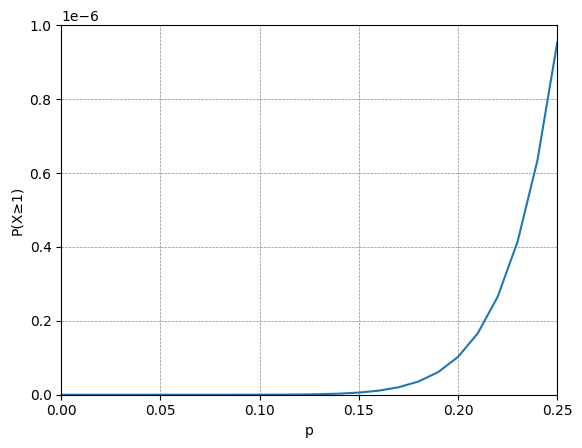

In [21]:
plt.plot([n/100 for n in range(26)], [BernoulliExperiment(10, p/100).prob_min(10) for p in range(26)])
plt.ylabel("P(X≥1)")
plt.xlabel("p")
plt.axis((0, 0.25, 0, 0.000001))
plt.grid(true, "major", "both", color='#888888', linestyle='--', linewidth=0.5)
plt.show()